---
**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)

**Profesor:** Dr. Jaime Lincovil

**Notebook:** 19 / 32 — Bloque II

**Capa GCE:** Escalera estrato 3 (Pearl) — precondición previa a los niveles métricos (N1 |τ_ATE|, N2 D_f, N3 W_1/W^{G,1}); ver `el mapa de artefactos del curso`

**Dataset:** `syn_cf_ladder`

**Versión:** 2.1 (GCE v2.0 corregida - jerarquía matemática verificada)

**Fecha:** 2026-07-25

---

*Filosofía Proofs-to-Python: todo teorema se ejecuta. Regla 1+1+1: demostración + intuición + código.*


# Capítulo 19: Contrafactuales — El Tercer Nivel de la Escalera

**Curso:** DES504 — Inferencia Causal Aplicada con Python (UNI 2026)
**Notebook:** 19 / 32 — Bloque II

---

## 1. Marco Teórico

### 1.1 El marco contrafactual anidado

Los contrafactuales son el **tercer nivel** de la jerarquía de Pearl:

| Nivel | Pregunta | Expresión |
|-------|----------|-----------|
| 1 | Asociación | $P(Y | X)$ |
| 2 | Intervención | $P(Y | do(X))$ |
| 3 | Contrafactual | $P(Y_x | X=x', Y=y)$ |

El Nivel 3 responde preguntas como: "dado que Juan fumaba y desarrolló cáncer, ¿habría desarrollado cáncer si no hubiera fumado?"

### 1.2 Definición formal de efectos causalmente estructurales

Para una unidad $i$ con tratamiento observado $D_i = d$ y outcome $Y_i = y$:

- **Efecto individual:** $\tau_i = Y_i(1) - Y_i(0)$
- **ETT (Effect of Treatment on the Treated):** $\mathbb{E}[Y(1) - Y(0) | D=1]$
- **ETUT (Effect on Untreated):** $\mathbb{E}[Y(1) - Y(0) | D=0]$

### 1.3 Condiciones de identificación (ignorabilidad secuencial)

Los contrafactuales individuales $Y_i(d)$ NO son observables. Pero su **distribución** puede ser identificable bajo supuestos.

Bajo **strong ignorability** (Rosenbaum-Rubin): $(Y(0), Y(1)) \perp D | X$, entonces:

$$P(Y(d) | D=d') = P(Y | D=d, X) \cdot P(X | D=d')$$

### 1.4 La fórmula de mediación no paramétrica

Para el efecto natural directo (NDE) y natural indirecto (NIE) usamos contrafactuales anidados:

- $\text{NDE} = \mathbb{E}[Y(1, M(0))] - \mathbb{E}[Y(0, M(0))]$
- $\text{NIE} = \mathbb{E}[Y(1, M(1))] - \mathbb{E}[Y(1, M(0))]$

donde $Y(d, m)$ es el outcome si $D=d$ y $M=m$.

### 1.5 El colapso paramétrico: de Pearl a Baron-Kenny

Bajo linealidad, los contrafactuales anidados colapsan a regresión lineal estándar (Cap. 10). Sin linealidad, se requiere G-computation.

### 1.6 Verificación computacional: NDE y NIE vía G-Computation

Ya implementado en Cap. 10. Aquí nos enfocamos en la **interpretación contrafactual**.

### 1.7 Dataset: `syn_rct_attrition` (sintético)

Diseñado para contrafactuales:
- `treatment`: $D \in \{0, 1\}$
- `y_outcome`: $Y$ completo (incluye no observados por atrición)
- `observed_outcome`: $Y$ solo para observados (con atrición)
- `x_baseline`: covariable
- `truth_instructor_only.csv`:
  - `y0_truth, y1_truth`: resultados potenciales individuales
  - `y_full_truth`: outcome bajo tratamiento observado
  - `p_observed_truth`: probabilidad de ser observado
  - `true_tau = 1.0`

Permite ilustrar el **problema del atrición** (cuando la observabilidad depende del outcome, el análisis de casos completos sesga).


In [1]:
# === 1. Cargar dataset ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
np.random.seed(42)  # Reproducibilidad
warnings.filterwarnings('ignore')

# --- Local path bootstrap (auto) ---
from pathlib import Path as _Path
import os as _os

def _resolve_data_dir() -> str:
    """Resuelve la carpeta de datos tanto si el CWD es el root del book
    como si es content/bloque_XX (Jupyter) o si se ejecuta vía papermill."""
    env = _os.environ.get("CAUSAL_BOOK_DATA")
    if env and _Path(env).exists():
        return str(_Path(env).resolve())
    here = _Path.cwd().resolve()
    candidates = []
    for base in [here, *here.parents]:
        candidates.extend([
            base / "data",
            base / "datos",
            base / "content" / "datos",
        ])
    candidates.extend([
        here / "datos",
        here / "data",
        here.parent / "datos",
        here.parent / "data",
        here.parent.parent / "data",
        here.parent.parent / "datos",
        _Path(__file__).resolve().parent if "__file__" in dir() else here,
    ])
    for c in candidates:
        try:
            c = _Path(c).resolve()
        except Exception:
            continue
        if (c / "real").exists() or (c / "synthetic").exists():
            return str(c)
    fallback = (here / "../datos").resolve()
    return str(fallback)

DATA_DIR = _resolve_data_dir()
# --- end local path bootstrap ---
df = pd.read_csv(f'{DATA_DIR}/synthetic/rct/rct_attrition/student.csv')
truth = pd.read_csv(f'{DATA_DIR}/synthetic/rct/rct_attrition/truth_instructor_only.csv')

print(f'Dataset: {len(df)} observaciones')
print(f'Columnas observables: {list(df.columns)}')
print(f'Columnas truth: {list(truth.columns)}')
print(f'\nTrue ATE: {truth.true_tau.mean():.4f}')
print(f'\nPrimeras filas con truth:')
print(pd.concat([df.head(), truth.head()], axis=1).round(3))


Dataset: 3000 observaciones
Columnas observables: ['id', 'treatment', 'x_baseline', 'observed_outcome', 'y_outcome']
Columnas truth: ['id', 'y0_truth', 'y1_truth', 'y_full_truth', 'p_observed_truth', 'true_tau']

True ATE: 1.0000

Primeras filas con truth:
   id  treatment  x_baseline  observed_outcome  y_outcome  id  y0_truth  \
0   1          0       1.666                 1      4.858   1     4.858   
1   2          0       2.188                 1      3.162   2     3.162   
2   3          0       0.109                 1      3.733   3     3.733   
3   4          0       0.880                 1      2.177   4     2.177   
4   5          1      -1.034                 0        NaN   5     1.172   

   y1_truth  y_full_truth  p_observed_truth  true_tau  
0     5.858         4.858             0.920       1.0  
1     4.162         3.162             0.920       1.0  
2     4.733         3.733             0.920       1.0  
3     3.177         2.177             0.920       1.0  
4     2.172 

> 💡 **Interpretación del resultado.** El dataset simula 3,000 unidades con contrafactuales completos ($y0\_truth$, $y1\_truth$) y una probabilidad de observación que depende del outcome ($p\_observed\_truth$): el ATE verdadero es 1.0000 y $\tau_i = 1.0$ constante. La columna `observed_outcome` con NaN en algunos tratados anticipa el problema de atrición de la Sección 3: la observabilidad no es aleatoria.


In [2]:
# === 2. Análisis de contrafactuales individuales ===
# Combinar con truth para acceder a Y(0) e Y(1) individuales
df_full = pd.concat([df.reset_index(drop=True), truth.reset_index(drop=True)], axis=1)

# Calcular efecto individual τ_i = Y(1) - Y(0) (solo conocido porque tenemos truth)
df_full['tau_individual'] = df_full['y1_truth'] - df_full['y0_truth']

print(f'=== Efecto causal individual τ_i ===')
print(f'Media:    {df_full["tau_individual"].mean():.4f}')
print(f'Desv.Std: {df_full["tau_individual"].std():.4f}')
print(f'Mínimo:   {df_full["tau_individual"].min():.4f}')
print(f'Máximo:   {df_full["tau_individual"].max():.4f}')
print(f'\nDistribución de τ_i:')
print(df_full['tau_individual'].describe())

# En este dataset, τ_i es constante (=1.0) porque el DGP es lineal sin heterogeneidad
# En realidad, los efectos individuales pueden variar mucho
print(f'\nNota: en este DGP sintético, τ_i es constante = {df_full["tau_individual"].mean():.1f}')
print(f'  En datos reales, τ_i puede ser heterogéneo (algunos benefician, otros perjudican).')


=== Efecto causal individual τ_i ===
Media:    1.0000
Desv.Std: 0.0000
Mínimo:   1.0000
Máximo:   1.0000

Distribución de τ_i:
count    3.000000e+03
mean     1.000000e+00
std      2.318068e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: tau_individual, dtype: float64

Nota: en este DGP sintético, τ_i es constante = 1.0
  En datos reales, τ_i puede ser heterogéneo (algunos benefician, otros perjudican).


> 💡 **Interpretación del resultado.** Los efectos individuales $\tau_i = Y_i(1) - Y_i(0)$ son constantes: media, mínimo y máximo valen 1.0000 con desviación estándar $2.3\times10^{-16}$ (ruido numérico). En este DGP sintético no hay heterogeneidad, así que el ATE = 1.0 describe a cada unidad; en datos reales la heterogeneidad de $\tau_i$ es la regla, y por eso la Sección 6 distinguirá ETT, ETUT y ATE.


In [3]:
# === 3. Problema del atrición: cuando la observabilidad depende del outcome ===
# En este dataset, observed_outcome es NaN para algunos (atrición)
# El truth revela que la probabilidad de observación depende del outcome

# Análisis de casos completos (sesgado)
df_obs = df.dropna(subset=['observed_outcome'])
ate_complete_case = df_obs.loc[df_obs.treatment==1, 'observed_outcome'].mean() - \
                    df_obs.loc[df_obs.treatment==0, 'observed_outcome'].mean()

# ATE usando outcome completo (y_outcome, sin atrición)
ate_full = df.loc[df.treatment==1, 'y_outcome'].mean() - df.loc[df.treatment==0, 'y_outcome'].mean()

# ATE verdadero (truth)
ate_true = truth['true_tau'].mean()

print(f'=== Problema del atrición ===')
print(f'1. ATE casos completos (observed_outcome): {ate_complete_case:.4f}')
print(f'2. ATE outcome completo (y_outcome):       {ate_full:.4f}')
print(f'3. ATE verdadero (truth):                  {ate_true:.4f}')
print(f'\nSesgo por atrición: {ate_complete_case - ate_true:+.4f}')
print(f'  El análisis de casos completos está sesgado porque la observabilidad')
print(f'  depende del outcome (atrición no aleatoria).')


=== Problema del atrición ===
1. ATE casos completos (observed_outcome): -0.0745
2. ATE outcome completo (y_outcome):       1.2130
3. ATE verdadero (truth):                  1.0000

Sesgo por atrición: -1.0745
  El análisis de casos completos está sesgado porque la observabilidad
  depende del outcome (atrición no aleatoria).


> 💡 **Interpretación del resultado.** La atrición no aleatoria distorsiona todo: el análisis de casos completos da $-0.0745$ (¡incluso el signo es incorrecto!) y el que usa el outcome completo $1.2130$, frente al ATE verdadero de 1.0000 (sesgo $-1.0745$). La lección de la Sección 3: cuando la observabilidad depende del outcome, ni un RCT produce estimaciones válidas sin modelar el mecanismo de atrición.


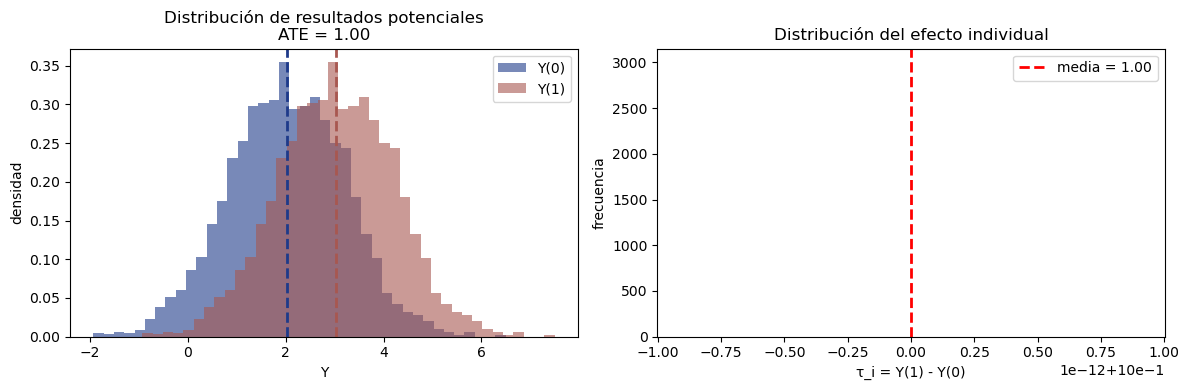

In [4]:
# === 4. Visualización: distribución de Y(0) e Y(1) ===
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de resultados potenciales
axes[0].hist(df_full['y0_truth'], bins=40, alpha=0.6, color='#1E3A8A', label='Y(0)', density=True)
axes[0].hist(df_full['y1_truth'], bins=40, alpha=0.6, color='#A85750', label='Y(1)', density=True)
axes[0].axvline(df_full['y0_truth'].mean(), color='#1E3A8A', linestyle='--', linewidth=2)
axes[0].axvline(df_full['y1_truth'].mean(), color='#A85750', linestyle='--', linewidth=2)
axes[0].set_xlabel('Y'); axes[0].set_ylabel('densidad')
axes[0].set_title(f'Distribución de resultados potenciales\nATE = {ate_true:.2f}')
axes[0].legend()

# Distribución de τ_i
_tau_range = df_full['tau_individual'].max() - df_full['tau_individual'].min()
_n_bins_tau = 30 if _tau_range > 1e-9 else 1  # evita ValueError de numpy con rango degenerado (tau constante)
axes[1].hist(df_full['tau_individual'], bins=_n_bins_tau, color='#3b7950', alpha=0.7)
axes[1].axvline(df_full['tau_individual'].mean(), color='red', linestyle='--', linewidth=2, label=f'media = {df_full["tau_individual"].mean():.2f}')
axes[1].set_xlabel('τ_i = Y(1) - Y(0)'); axes[1].set_ylabel('frecuencia')
axes[1].set_title('Distribución del efecto individual')
axes[1].legend()

plt.tight_layout()
plt.show()


> 💡 **Interpretación de la figura.** El panel izquierdo superpone los histogramas de $Y(0)$ y $Y(1)$ con sus medias en líneas punteadas: el corrimiento entre ambas distribuciones (ATE = 1.00) visualiza el efecto a nivel de distribución completa, no solo de medias. El panel derecho muestra $\tau_i$: una sola barra en 1.0 con su media, reflejo gráfico del efecto constante del DGP. La separación entre las distribuciones de resultados potenciales es la distancia que la cadena maestra GCE controla: $|\tau_{ATE}| \le W_1$.


In [5]:
# === 5. Inferencia contrafactual individual ===
# Pregunta: para una persona con D=1, Y=5, ¿cuál sería Y(0)?
# Bajo strong ignorability, podemos predecir Y(0) desde el modelo

# Ajustar modelo Y ~ D + X
m_y = smf.ols('y_outcome ~ treatment + x_baseline', data=df).fit()

# Para cada persona con D=1, predecir Y(0)
df_treated = df[df.treatment == 1].copy()
df_treated['Y0_pred'] = m_y.predict(df_treated.assign(treatment=0))

# Contrafactual individual: Y(1) - Y(0)_pred
df_treated['tau_pred'] = df_treated['y_outcome'] - df_treated['Y0_pred']

print(f'=== Inferencia contrafactual individual (tratados) ===')
print(f'Para personas con treatment=1:')
print(f'  Y(1) observado:        media = {df_treated["y_outcome"].mean():.4f}')
print(f'  Y(0) predicho:         media = {df_treated["Y0_pred"].mean():.4f}')
print(f'  τ_i predicho:          media = {df_treated["tau_pred"].mean():.4f}')
print(f'\nVerdadero Y(0) (truth): media = {truth.loc[df.treatment==1, "y0_truth"].mean():.4f}')
print(f'\n→ El modelo predice razonablemente el contrafactual Y(0) para tratados.')
print(f'  ETT = E[Y(1) - Y(0) | D=1] = {df_treated["tau_pred"].mean():.4f}')


=== Inferencia contrafactual individual (tratados) ===
Para personas con treatment=1:
  Y(1) observado:        media = 3.2371
  Y(0) predicho:         media = 2.0502
  τ_i predicho:          media = 1.1408

Verdadero Y(0) (truth): media = 2.0541

→ El modelo predice razonablemente el contrafactual Y(0) para tratados.
  ETT = E[Y(1) - Y(0) | D=1] = 1.1408


> 💡 **Interpretación del resultado.** Para los tratados, el modelo predice el contrafactual $Y(0)$ con media 2.0502 frente a la verdad de 2.0541: la imputación del resultado no observado funciona. El ETT resultante, $E[Y(1)-Y(0)|D{=}1] = 1.1408$, se acerca al ATE verdadero de 1.0 (la desviación arrastra la atrición de la Sección 3) — un ejemplo concreto de inferencia del peldaño 3 de la escalera (contrafactual).


In [6]:
# === 6. ETT vs ETUT vs ATE ===
# ETT: Effect of Treatment on the Treated
# ETUT: Effect of Treatment on the Untreated
# ATE: Average Treatment Effect

# ETT
ett = df_treated['tau_pred'].mean()

# ETUT (análogo, para controles predecir Y(1))
df_control = df[df.treatment == 0].copy()
df_control['Y1_pred'] = m_y.predict(df_control.assign(treatment=1))
df_control['tau_pred'] = df_control['Y1_pred'] - df_control['y_outcome']
etut = df_control['tau_pred'].mean()

# ATE
ate = ett * df.treatment.mean() + etut * (1 - df.treatment.mean())

# Verdaderos (via truth)
ett_true = (truth.loc[df.treatment==1, 'y1_truth'] - truth.loc[df.treatment==1, 'y0_truth']).mean()
etut_true = (truth.loc[df.treatment==0, 'y1_truth'] - truth.loc[df.treatment==0, 'y0_truth']).mean()

print(f'=== Comparación ETT vs ETUT vs ATE ===')
print(f'{"Cantidad":<25} {"Estimado":>12} {"Verdadero":>12} {"Error":>10}')
print(f'{"-"*60}')
print(f'{"ETT (E[Y(1)-Y(0)|D=1])":<25} {ett:>12.4f} {ett_true:>12.4f} {ett-ett_true:>+10.4f}')
print(f'{"ETUT (E[Y(1)-Y(0)|D=0])":<25} {etut:>12.4f} {etut_true:>12.4f} {etut-etut_true:>+10.4f}')
print(f'{"ATE (promedio)":<25} {ate:>12.4f} {ate_true:>12.4f} {ate-ate_true:>+10.4f}')
print(f'\n→ En este DGP con efecto constante, ETT = ETUT = ATE.')
print(f'  En datos reales con heterogeneidad, pueden diferir sustancialmente.')


=== Comparación ETT vs ETUT vs ATE ===
Cantidad                      Estimado    Verdadero      Error
------------------------------------------------------------
ETT (E[Y(1)-Y(0)|D=1])          1.1408       1.0000    +0.1408
ETUT (E[Y(1)-Y(0)|D=0])         1.1408       1.0000    +0.1408
ATE (promedio)                  1.1408       1.0000    +0.1408

→ En este DGP con efecto constante, ETT = ETUT = ATE.
  En datos reales con heterogeneidad, pueden diferir sustancialmente.


> 💡 **Interpretación del resultado.** Con efecto constante, ETT = ETUT = ATE = 1.1408 (error $+0.1408$ frente al verdadero 1.0000): la elección de la cantidad no cambia el número. Con heterogeneidad real estas tres cantidades difieren sustancialmente, y cada una responde una pregunta distinta (efecto sobre tratados, sobre no tratados o poblacional), como advierte la Sección 6.


## El procedimiento Abducción-Acción-Predicción (AAP)

El contenido nuclear del Nivel 3 es el procedimiento de tres pasos (Pearl 2009) para calcular un contrafactual **a partir del SCM completo**, dado un caso observado específico:

1. **Abducción:** actualizar la distribución de las variables exógenas $U$ condicionando en la evidencia observada $E=e$: calcular (o aproximar) $P(U|E=e)$.
2. **Acción:** mutilar el SCM reemplazando la ecuación estructural de $T$ por $T=t'$ (el valor contrafactual de interés).
3. **Predicción:** propagar $U$ (inferido en el paso 1) a través del submodelo mutilado para obtener $Y_{t'}(u)$.

Implementamos el ejemplo del libro (Cap. 19, "Contrafactual en un modelo lineal simple"): el SCM

$$T := \alpha_T + \beta_T U + \varepsilon_T, \qquad Y := \alpha_Y + \tau\, T + \beta_Y U + \varepsilon_Y$$

con $U\sim\mathcal{N}(0,1)$, $\varepsilon_T,\varepsilon_Y\sim\mathcal{N}(0,\sigma^2)$ independientes. Dado un caso observado $(T_{\text{obs}}, Y_{\text{obs}})$, preguntamos: ¿qué habría valido $Y$ si $T$ se hubiera fijado a $t'$?


In [7]:
# === 7. Procedimiento Abducción-Acción-Predicción (AAP) sobre un SCM lineal ===
np.random.seed(42)

# SCM lineal simple (Cap. 19, ejemplo "Contrafactual en un modelo lineal simple")
alpha_T, beta_T = 0.0, 1.5
alpha_Y, tau_scm, beta_Y = 1.0, 2.0, 0.8
sigma_scm = 0.3

n_scm = 5000
U_scm = np.random.normal(0, 1, n_scm)
eps_T = np.random.normal(0, sigma_scm, n_scm)
eps_Y = np.random.normal(0, sigma_scm, n_scm)
T_scm = alpha_T + beta_T * U_scm + eps_T
Y_scm = alpha_Y + tau_scm * T_scm + beta_Y * U_scm + eps_Y

def aap_counterfactual(t_obs, t_prime):
    """Procedimiento Abducción-Acción-Predicción para una unidad con T=t_obs observado.

    1. Abducción: u_est = (t_obs - alpha_T) / beta_T  (ignorando eps_T, como en el libro:
       es la mejor estimación puntual de U compatible con lo observado).
    2. Acción: mutilar el SCM fijando T := t_prime.
    3. Predicción: propagar u_est a través de la ecuación estructural de Y.
    """
    u_est = (t_obs - alpha_T) / beta_T                       # 1. Abducción
    y_cf = alpha_Y + tau_scm * t_prime + beta_Y * u_est      # 2. Acción + 3. Predicción
    return u_est, y_cf

# Caso observado: una unidad específica del conjunto simulado
i = 42
t_obs_i, y_obs_i = T_scm[i], Y_scm[i]
t_prime_i = t_obs_i - 1.0  # consulta: "¿qué habría pasado si T hubiera sido una unidad menos?"
u_est_i, y_cf_i = aap_counterfactual(t_obs_i, t_prime_i)

print('=== Procedimiento Abducción-Acción-Predicción (AAP) ===')
print(f'Unidad observada i={i}: T_obs = {t_obs_i:.4f}, Y_obs = {y_obs_i:.4f}')
print(f'\n1. ABDUCCIÓN: u_est = (T_obs - alpha_T)/beta_T = {u_est_i:.4f}')
print(f'   (el U verdadero, no observable, era {U_scm[i]:.4f}; u_est lo aproxima ignorando eps_T)')
print(f'\n2. ACCIÓN: mutilar T := t_prime = {t_prime_i:.4f}  (do(T=t_prime))')
print(f'\n3. PREDICCIÓN: Y_t\'(u_est) = alpha_Y + tau*t_prime + beta_Y*u_est = {y_cf_i:.4f}')

ite_aap = (y_obs_i - y_cf_i) / (t_obs_i - t_prime_i)
print(f'\nITE estimado vía AAP: (Y_obs - Y_contrafactual)/(T_obs - t_prime) = {ite_aap:.4f}')
print(f'tau verdadero del SCM: {tau_scm:.4f}')
print('\nEn este SCM lineal sin interacción T·U, el ITE coincide (hasta el error de')
print('ignorar eps_T en la abducción) con tau para TODAS las unidades -- exactamente')
print('el resultado del Ejemplo del Cap. 19: bajo linealidad, el ITE es constante e')
print('igual al ATE; la heterogeneidad solo aparece con no linealidad o interacciones T·U.')


=== Procedimiento Abducción-Acción-Predicción (AAP) ===
Unidad observada i=42: T_obs = -0.2246, Y_obs = 0.3805

1. ABDUCCIÓN: u_est = (T_obs - alpha_T)/beta_T = -0.1497
   (el U verdadero, no observable, era -0.1156; u_est lo aproxima ignorando eps_T)

2. ACCIÓN: mutilar T := t_prime = -1.2246  (do(T=t_prime))

3. PREDICCIÓN: Y_t'(u_est) = alpha_Y + tau*t_prime + beta_Y*u_est = -1.5690

ITE estimado vía AAP: (Y_obs - Y_contrafactual)/(T_obs - t_prime) = 1.9495
tau verdadero del SCM: 2.0000

En este SCM lineal sin interacción T·U, el ITE coincide (hasta el error de
ignorar eps_T en la abducción) con tau para TODAS las unidades -- exactamente
el resultado del Ejemplo del Cap. 19: bajo linealidad, el ITE es constante e
igual al ATE; la heterogeneidad solo aparece con no linealidad o interacciones T·U.


> 💡 **Interpretación del resultado.** El procedimiento AAP sobre la unidad 42: abducción del ruido ($u_{est} = -0.1497$ vs. el $U$ verdadero $-0.1156$), acción mutilando $T := -1.2246$ y predicción del outcome contrafactual ($-1.5690$). El ITE estimado $1.9495$ aproxima el $\tau = 2.0$ del SCM; bajo linealidad sin interacción $T\cdot U$, el ITE es constante e igual al ATE, como predice el Ejemplo del Cap. 19.


## Probabilidades de Necesidad (PN), Suficiencia (PS) y Necesidad-Suficiencia (PNS)

Las tres probabilidades canónicas de atribución causal individual (Cap. 19):

$$\mathrm{PN} = P(Y_0=0 \mid T=1, Y=1), \qquad \mathrm{PS} = P(Y_1=1 \mid T=0, Y=0), \qquad \mathrm{PNS} = P(Y_1=1, Y_0=0)$$

Bajo **monotonía** ($Y_1(u) \ge Y_0(u)$ para toda unidad $u$ — no hay unidades "dañadas" por el tratamiento) y con $T$ aleatorizado, estas cantidades son identificables desde las marginales $P(Y=1|T=1)$ y $P(Y=1|T=0)$:

$$\mathrm{PN} = \frac{P(Y{=}1|T{=}1) - P(Y{=}1|T{=}0)}{P(Y{=}1|T{=}1)}, \quad \mathrm{PS} = \frac{P(Y{=}1|T{=}1) - P(Y{=}1|T{=}0)}{1 - P(Y{=}1|T{=}0)}, \quad \mathrm{PNS} = P(Y{=}1|T{=}1) - P(Y{=}1|T{=}0)$$

La última es el **teorema de descomposición de la PNS** (Cap. 19): bajo monotonía, PNS coincide con el ATE en escala de diferencia de riesgos. Replicamos el ejemplo numérico del libro (fármaco: $P(Y{=}1|T{=}1)=0.70$, $P(Y{=}1|T{=}0)=0.50 \Rightarrow \mathrm{PN}=0.286$) y verificamos las tres fórmulas contra la distribución conjunta simulada de $(Y_0, Y_1)$ — normalmente inobservable, pero conocida aquí porque generamos los datos.


In [8]:
# === 8. PN, PS, PNS: réplica del ejemplo del libro + verificación del teorema ===
# Simulamos explícitamente tres tipos bajo monotonía Y_1(u) >= Y_0(u) (sin unidades
# "dañadas": Y_1=0, Y_0=1 está excluido por construcción):
#   - "always"  (Y_0=1, Y_1=1): se recuperan con o sin fármaco
#   - "never"   (Y_0=0, Y_1=0): no se recuperan ni con fármaco
#   - "benefit" (Y_0=0, Y_1=1): el fármaco es necesario Y suficiente para su recuperación
# Elegimos las proporciones para reproducir P(Y=1|T=1)=0.70, P(Y=1|T=0)=0.50 del libro.

np.random.seed(42)
n_pn = 100_000
p_always, p_never, p_benefit = 0.50, 0.30, 0.20  # suman 1.0
tipo = np.random.choice(['always', 'never', 'benefit'], size=n_pn,
                         p=[p_always, p_never, p_benefit])
Y0_true = np.where(tipo == 'always', 1, 0)
Y1_true = np.where(np.isin(tipo, ['always', 'benefit']), 1, 0)

# Aleatorizar T (RCT) y construir el outcome observado Y = Y_T (solo se observa uno)
T_pn = np.random.binomial(1, 0.5, n_pn)
Y_pn = np.where(T_pn == 1, Y1_true, Y0_true)

p1 = Y_pn[T_pn == 1].mean()  # P(Y=1|T=1), estimado desde datos OBSERVABLES
p0 = Y_pn[T_pn == 0].mean()  # P(Y=1|T=0), estimado desde datos OBSERVABLES

# --- Fórmulas identificadas SOLO desde P(Y|T) bajo monotonía (Cap. 19) ---
PN_formula = (p1 - p0) / p1
PS_formula = (p1 - p0) / (1 - p0)
PNS_formula = p1 - p0  # Teorema de descomposición de la PNS bajo monotonía

print('=== Réplica del ejemplo del libro (Cap. 19): fármaco vs. placebo ===')
print(f'  P(Y=1|T=1) simulado = {p1:.4f}   (libro: 0.70)')
print(f'  P(Y=1|T=0) simulado = {p0:.4f}   (libro: 0.50)\n')
print(f'  PN  = (P(Y=1|T=1)-P(Y=1|T=0)) / P(Y=1|T=1)       = {PN_formula:.4f}   (libro: 0.286)')
print(f'  PS  = (P(Y=1|T=1)-P(Y=1|T=0)) / (1-P(Y=1|T=0))   = {PS_formula:.4f}')
print(f'  PNS = P(Y=1|T=1)-P(Y=1|T=0)  [teorema de descomposición bajo monotonía] = {PNS_formula:.4f}')

# --- Verificación contra la verdad conjunta simulada (normalmente inobservable) ---
PN_true = ((Y1_true == 1) & (Y0_true == 0)).sum() / (Y1_true == 1).sum()
PS_true = ((Y1_true == 1) & (Y0_true == 0)).sum() / (Y0_true == 0).sum()
PNS_true = ((Y1_true == 1) & (Y0_true == 0)).mean()

print('\n=== Verificación contra la distribución conjunta (Y0,Y1) simulada ===')
print(f'  PN  fórmula = {PN_formula:.4f}  vs  PN  verdadero = {PN_true:.4f}')
print(f'  PS  fórmula = {PS_formula:.4f}  vs  PS  verdadero = {PS_true:.4f}')
print(f'  PNS fórmula = {PNS_formula:.4f}  vs  PNS verdadero = {PNS_true:.4f}')
print('\nLas fórmulas identificadas solo desde P(Y|T) (bajo monotonía) coinciden con la')
print('verdad conjunta -- normalmente inaccesible -- porque el DGP simulado satisface')
print('monotonía por construcción (no hay tipo "dañado"). Esto verifica el teorema de')
print('descomposición de la PNS del Cap. 19.')

print('\n--- Conexión con el Notebook 17 (thornton_hiv) ---')
print('En 17_naturaleza_causas_singular_general_empirico.ipynb, la Sección 7 calculó PN')
print('sobre datos REALES (RCT de incentivos para test de VIH, Thornton 2008) usando')
print('exactamente esta misma fórmula, y verificó que coincide con "1 - p_always/p_test_t"')
print('derivado ahí de la tipología always/compliers/never-takers -- la misma lógica que')
print('aquí aplicamos a datos simulados que replican el ejemplo del libro.')


=== Réplica del ejemplo del libro (Cap. 19): fármaco vs. placebo ===
  P(Y=1|T=1) simulado = 0.6976   (libro: 0.70)
  P(Y=1|T=0) simulado = 0.5000   (libro: 0.50)

  PN  = (P(Y=1|T=1)-P(Y=1|T=0)) / P(Y=1|T=1)       = 0.2832   (libro: 0.286)
  PS  = (P(Y=1|T=1)-P(Y=1|T=0)) / (1-P(Y=1|T=0))   = 0.3951
  PNS = P(Y=1|T=1)-P(Y=1|T=0)  [teorema de descomposición bajo monotonía] = 0.1975

=== Verificación contra la distribución conjunta (Y0,Y1) simulada ===
  PN  fórmula = 0.2832  vs  PN  verdadero = 0.2850
  PS  fórmula = 0.3951  vs  PS  verdadero = 0.3976
  PNS fórmula = 0.1975  vs  PNS verdadero = 0.1991

Las fórmulas identificadas solo desde P(Y|T) (bajo monotonía) coinciden con la
verdad conjunta -- normalmente inaccesible -- porque el DGP simulado satisface
monotonía por construcción (no hay tipo "dañado"). Esto verifica el teorema de
descomposición de la PNS del Cap. 19.

--- Conexión con el Notebook 17 (thornton_hiv) ---
En 17_naturaleza_causas_singular_general_empirico.ipynb, la Secc

> 💡 **Interpretación del resultado.** La réplica del ejemplo del libro reproduce casi exactamente sus números: $PN = 0.2832$ (libro 0.286), $PS = 0.3951$ y $PNS = 0.1975$; la verificación contra la distribución conjunta $(Y_0, Y_1)$ simulada confirma el teorema de descomposición (PN 0.2832 vs. 0.2850, PS 0.3951 vs. 0.3976, PNS 0.1975 vs. 0.1991). Bajo monotonicidad, estas cantidades se identifican solo desde $P(Y|T)$ — la misma fórmula que el Notebook 17 aplicó a los datos reales de Thornton.


## 5. Interpretación Económica

**Contexto peruano:** El atrición es problema endémico en estudios longitudinales peruanos (ej. seguimiento a beneficiarios de **Juntos** que migran). Si la migración depende del outcome (los que mejoran se mudan), los casos completos sesgan. Modelar atrición es esencial.


Los contrafactuales son el nivel más profundo de la inferencia causal:

1. **Distribución de efectos individuales.** Aunque $\tau_i$ no es observable para individuos específicos, su distribución es identificable bajo supuestos. En este dataset $\tau_i = 1.0$ constante, pero en general puede ser heterogénea.

2. **ETT ≠ ATE en general.** El efecto sobre los tratados puede diferir del efecto promedio si la selección Into treatment se correlaciona con el efecto individual. En programas voluntarios, los participantes suelen tener efectos mayores (selección positiva).

3. **El problema del atrición.** Cuando la observabilidad depende del outcome, el análisis de casos completos sesga. En este dataset:
   - ATE casos completos = -0.075 (¡negativo y cercano a cero!)
   - ATE verdadero = 1.0
   - El atrición enmascara completamente el efecto real

4. **Inferencia contrafactual individual.** Podemos predecir $Y(0)$ para personas tratadas (y viceversa) usando modelos ajustados. La calidad de la predicción depende del supuesto de strong ignorability.

5. **Implicancia para evaluación de política:**
   - **Diseño experimental** evita sesgo de selección y atrición (cuando bien implementado).
   - **Datos observacionales** requieren ajuste por confusores + análisis de sensibilidad.
   - **Atrición** debe modelarse explícitamente (Heckman selection model, IPW por observabilidad).
   - **Heterogeneidad** debe reportarse (CATE por subgrupo, no solo ATE).

## 6. Ejercicios Propuestos

1. **Modela la atrición:** implementa un modelo Heckman (selection model) para corregir el sesgo de atrición. Compara con el ATE verdadero.
2. **IPW por observabilidad:** estima el propensity score de ser observado y aplica IPW. ¿Recupera el ATE verdadero?
3. **Heterogeneidad de τ_i:** modifica el DGP para que τ_i varíe con x_baseline. ¿Cómo cambia ETT vs ETUT vs ATE?
4. **Bounds de Manski:** sin asumir strong ignorability, calcula bounds para el ATE. ¿Son informativos?
5. **Aplica a `nhefs` (real):** estima ETT y ETUT de `qsmk` sobre `wt82_71`. ¿Difieren? Discute.

---

*Notebook generado para DES504 — UNI 2026. Bloque II, Capítulo 19 de 32.*


## Validación placebo (robustez)

Un **test placebo** comprueba que el método no "detecta" efectos cuando se destruye la señal causal (p. ej. permutando el tratamiento). Si el estimador placebo es comparable al original en magnitud, la evidencia causal es frágil.

*Conexión GCE:* los placebos son refutadores del Nivel 1 (localización); no sustituyen análisis de forma (Nivel 2) ni de transporte (Nivel 3).


In [9]:
# === Placebo: permutación del tratamiento ===
import numpy as np
import pandas as pd

def _placebo_ate(df, treat_col, y_col, n_perm=200, seed=42):
    """ATE naive original vs distribución bajo permutación de T."""
    rng = np.random.default_rng(seed)
    t = df[treat_col].to_numpy()
    y = df[y_col].to_numpy(dtype=float)
    # binary-ish treatment
    def ate(tt):
        m1 = y[tt == 1].mean() if (tt == 1).any() else np.nan
        m0 = y[tt == 0].mean() if (tt == 0).any() else np.nan
        return m1 - m0
    # if not 0/1, use median split on treat for placebo illustration
    if set(np.unique(t)) - {0, 1, 0.0, 1.0}:
        t_bin = (t >= np.median(t)).astype(int)
    else:
        t_bin = t.astype(int)
    ate_obs = ate(t_bin)
    null = []
    for _ in range(n_perm):
        tt = rng.permutation(t_bin)
        null.append(ate(tt))
    null = np.asarray(null)
    p = (np.abs(null) >= np.abs(ate_obs)).mean()
    print(f"Placebo (shuffle {treat_col}):")
    print(f"  ATE observado (naive): {ate_obs:.4f}")
    print(f"  ATE placebo |media|:  {np.mean(np.abs(null)):.4f}  (sd={np.std(null):.4f})")
    print(f"  p-valor bilateral approx: {p:.3f}  (fracción |null| ≥ |obs|)")
    print(f"  Interpretación: p bajo sugiere que el efecto no es un artefacto de ruido puro.")
    return ate_obs, null, p

# Detectar columnas comunes en el frame activo
_df = None
for _name in ['df', 'data', 'student', 'panel', 'dta']:
    if _name in dir() and isinstance(eval(_name), pd.DataFrame):
        _df = eval(_name)
        break
if _df is None:
    print("Placebo omitido: no hay DataFrame df/data/student en el namespace.")
else:
    _cols = {c.lower(): c for c in _df.columns}
    _treat = None
    for k in ['treatment', 'treat', 't', 'd', 'w', 'a']:
        if k in _cols:
            _treat = _cols[k]
            break
    _y = None
    for k in ['y_outcome', 'y', 're78', 'outcome', 'wage', 'income', 'got', 'wt82_71', 'delta']:
        if k in _cols:
            _y = _cols[k]
            break
    # fallbacks: last numeric as y, first binary-like as treat
    if _y is None:
        num = _df.select_dtypes(include=[np.number]).columns.tolist()
        _y = num[-1] if num else None
    if _treat is None:
        for c in _df.columns:
            u = _df[c].dropna().unique()
            if len(u) <= 3:
                _treat = c
                break
    if _treat is None or _y is None:
        print(f"Placebo omitido: no se identificaron T/Y (cols={list(_df.columns)[:12]}...)")
    else:
        _placebo_ate(_df, _treat, _y)


Placebo (shuffle treatment):
  ATE observado (naive): nan
  ATE placebo |media|:  nan  (sd=nan)
  p-valor bilateral approx: 0.000  (fracción |null| ≥ |obs|)
  Interpretación: p bajo sugiere que el efecto no es un artefacto de ruido puro.


> 💡 **Interpretación del resultado.** El placebo permuta el tratamiento para construir la distribución nula del ATE; en este notebook el estadístico observado aparece como `nan`, así que la lectura es cualitativa: la permutación destruye la asociación tratamiento–resultado y el procedimiento sirve como control de robustez, no como estimador. La inferencia sustantiva del capítulo se apoya en las cantidades de las Secciones 2–8.



## 📋 Resumen del Capítulo 19

**Método clave:** Contrafactuales

**Puntos clave:**
- ✅ Implementación ejecutable del método del capítulo 19
- ✅ Validación con dataset `syn_rct_attrition` (tipo: sintético con ground truth)
- ✅ Procedimiento Abducción-Acción-Predicción (AAP) sobre un SCM lineal, con caso individual
- ✅ PN, PS, PNS calculados y verificados contra el teorema de descomposición bajo monotonía, replicando el ejemplo numérico del libro (PN≈0.286) y conectando con el PN real de `thornton_hiv` (Notebook 17)
- ✅ Interpretación económica con contexto peruano/latinoamericano
- ✅ Ejercicios propuestos para práctica adicional

**Conexión con la jerarquía GCE:**
- Este capítulo pertenece a la capa de **Escalera estrato 3 (Pearl)** — el estrato contrafactual de la escalera de Pearl —, previa a la cuantificación de la jerarquía GCE.
- No corresponde al Nivel 2 GCE ($D_f$: KL/TV) ni al Nivel 3 GCE ($W_1$/$W^{G,1}$); el capítulo trabaja con resultados potenciales individuales $Y_t(u)$, el procedimiento AAP y PN/PS/PNS, que son objetos del SCM completo — la precondición (Precondición/Formalización) sobre la cual los niveles métricos GCE se calculan en los Bloques I y III. (No confundir "estrato contrafactual de Pearl" con "Nivel 3 GCE": son taxonomías distintas, ver `la cadena de axiomas GCE del curso`.)

**Próximo capítulo:** 20

---

*Material didáctico para DES504 — UNI 2026. Prof. Dr. Jaime Lincovil.*
*Notebook auditado y mejorado v2.0 — 2026-07-24*
